## Задание

В компании был проведен A/B-тест двух вариантов акционных предложений. Требуется оценить, какой из вариантов предложений показывает лучшие результаты. Для этого необходимо определить, какие метрики следует рассмотреть, и объяснить, каким образом их анализ поможет принять обоснованное решение.

In [ ]:
import requests
from urllib.parse import urlencode
import pandas as pd
from io import StringIO

# Загрузка файла с Яндекс диска
public_url = "*********"
api_url = "**********"

response = requests.get(api_url + urlencode({"public_key": public_url}))
download_url = response.json()["href"]

r = requests.get(download_url)

# Чтение CSV
df_task_2 = pd.read_csv(StringIO(r.text))

# Подготовка данных

df_task_2[['user_id', 'revenue','testgroup']] = df_task_2['user_id;revenue;testgroup'].str.split(';', expand=True)
df_task_2.drop(columns=['user_id;revenue;testgroup'], inplace=True)

#Приводим типы данных
df_task_2["user_id"] = df_task_2["user_id"].astype(int)
df_task_2["revenue"] = df_task_2["revenue"].astype(int)
df_task_2["testgroup"] = df_task_2["testgroup"].astype("category")

# Проверяем данные
print("Данные результатов A/B теста")
display(df_task_2.head())
print(df_task_2.isna().sum(), "\n Число строк", len(df_task_2), "\n Количество уникальных строк \n", df_task_2.nunique())

Данные результатов A/B теста


,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


user_id      0
revenue      0
testgroup    0
dtype: int64 
 Число строк 404770 
 Количество уникальных строк 
 user_id      404770
revenue        1477
testgroup         2
dtype: int64


#### Промежуточный вывод:
Данные по результатам A/B теста загружены, пустых значений нет, все значения уникальные. 

In [18]:
# Расчет метрик
metrics = (
    df_task_2
    .groupby("testgroup")
    .agg(
        users=("user_id", "nunique"),                 # количество пользователей всего
        payers=("revenue", lambda x: (x > 0).sum()),  # количество платящих пользователей
        total_revenue=("revenue", "sum"),             # общая выручка
        arpu=("revenue", "mean"),                     # средняя выручка
        arppu=("revenue", lambda x: x[x > 0].mean()), # средний чек платящего пользователя
        median_ppu=("revenue", lambda x: x[x > 0].median())                   # медиана revenue
    )
)

metrics["cr"] = metrics["payers"] / metrics["users"]  # доля платящих пользователей
metrics = metrics.round({"arpu": 2, "arppu": 2, "median_ppu": 2})
display(metrics)

,users,payers,total_revenue,arpu,arppu,median_ppu,cr
testgroup,,,,,,,
a,202103,1928,5136189,25.41,2664.00,311.0,0.009540
b,202667,1805,5421603,26.75,3003.66,3022.0,0.008906


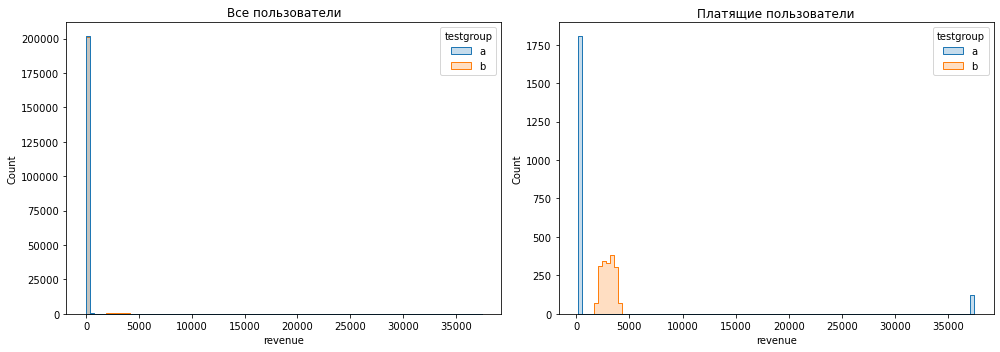

% пользователей с платежом > 35000 в группе A: 6.38%


In [19]:
# Визуализируем данные

# создаём фигуру с двумя осями
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

#  Все пользователи
sns.histplot(
    data=df_task_2,
    x="revenue",
    hue="testgroup",
    bins=100,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title("Все пользователи")

# Только платящие пользователи
sns.histplot(
    data=df_task_2[df_task_2["revenue"] > 0],
    x="revenue",
    hue="testgroup",
    bins=100,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("Платящие пользователи")
plt.tight_layout()
plt.show()

# платящие пользователи группы A
rev_a_ppu = df_task_2[
    (df_task_2["testgroup"] == "a") & (df_task_2["revenue"] > 0)
]
# пользователи с платежом > 35000
high_payers = rev_a_ppu[rev_a_ppu["revenue"] > 35000]
# процент
pct_high_payers = len(high_payers) / len(rev_a_ppu) * 100
print(f"% пользователей с платежом > 35000 в группе A: {pct_high_payers:.2f}%")

#### Промежуточные выводы

По итогам предварительных расчетов получены базовые показатели:

1) Размеры групп сопоставимы  
2) Суммарная выручка и ARPU выше в тестовой группе. То есть на одного пользователя в среднем выручка выше в тесте, но это пока описательно.  
3) Конверсия в платёж (CR) ниже в тестовой группе. То есть в тесте меньшая доля пользователей начинает платить.  
4) ARPPU выше в тестовой группе.  
5) Медианный платёж среди платящих радикально отличается. Это указывает на существенно разную структуру платежей (в контрольной группе платежи “мелкие у большинства”, в тестовой группе медианный платёж существенно выше, что указывает на смещение распределения платежей среди платящих пользователей в сторону более высоких значений). Это важный сигнал: эксперимент, вероятно, меняет модель монетизации

**Выбор метрик для дальнейшей статистической проверки.** 

1) Конверсия в платёж - CR <br>

CR является долевой метрикой, поэтому для её сравнения между группами целесообразно использовать двусторонний z-тест, который позволяет оценить статистическую значимость различий долей при больших размерах выборок.

2) Средняя выручка на одного пользователя ARPU и среди платящих пользователей ARPPU <br>

Поскольку ARPU и ARPPU представляют собой среднее значение количественной величины, для его сравнения между группами выбирается t-тест Уэлча с построением доверительного интервала для разницы средних. Объёмы выборок велики, что позволяет опираться на Центральную предельную теорему при оценке распределения среднего, а возможная неоднородность дисперсий между группами учитывается за счёт использования варианта Уэлча.

In [20]:
# 1) двусторонний z-тест конверсии в платёж (CR) 
# Проверка гипотезы: H_0: CR_a = CR_b
payers_a = metrics.loc["a", "payers"]
users_a = metrics.loc["a", "users"]
payers_b = metrics.loc["b", "payers"]
users_b = metrics.loc["b", "users"]

def two_proportion_z_test(x1, n1, x2, n2):
    p_pool = (x1 + x2) / (n1 + n2)
    se = sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (x2 / n2 - x1 / n1) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

z_cr, p_cr = two_proportion_z_test(
    payers_a, users_a,
    payers_b, users_b
)
print("\n""результаты CR теста")
print('z_value_cr = ', round(z_cr,2), '  p_value_cr = ', round(p_cr,3))
print("")

# 2)  t-тест Уэлча для ARPU

#  Данные для ARPU 
rev_a = df_task_2.loc[df_task_2["testgroup"] == "a", "revenue"]
rev_b = df_task_2.loc[df_task_2["testgroup"] == "b", "revenue"]

t_stat, p_value = stats.ttest_ind(
    rev_a,
    rev_b,
    equal_var=False  
)

print("t-тест Уэлча для ARPU")
print("t-statistic:", round(t_stat, 3))
print("p-value    :", round(p_value, 3))

#  Доверительный интервал разницы средних (B - A)
alpha = 0.05

mean_a = rev_a.mean()
mean_b = rev_b.mean()
var_a = rev_a.var(ddof=1)
var_b = rev_b.var(ddof=1)
n_a = len(rev_a)
n_b = len(rev_b)

diff_mean = mean_a - mean_b
se = np.sqrt(var_a / n_a + var_b / n_b)

# степени свободы по формуле Уэлча
df = (var_a / n_a + var_b / n_b) ** 2 / (
    (var_a / n_a) ** 2 / (n_a - 1) +
    (var_b / n_b) ** 2 / (n_b - 1)
)

t_crit = stats.t.ppf(1 - alpha / 2, df)

ci_low = diff_mean - t_crit * se
ci_high = diff_mean + t_crit * se

print(f"95% CI: [{round(ci_low, 3)}, {round(ci_high, 3)}]")


# 3) t-тест Уэлча для ARPPU (только платящие пользователи)

# Данные для ARPPU (только revenue > 0)
pay_a = df_task_2.loc[
    (df_task_2["testgroup"] == "a") & (df_task_2["revenue"] > 0),
    "revenue"
]
pay_b = df_task_2.loc[
    (df_task_2["testgroup"] == "b") & (df_task_2["revenue"] > 0),
    "revenue"
]

t_stat, p_value = stats.ttest_ind(
    pay_a,
    pay_b,
    equal_var=False
)

print("\n""t-тест Уэлча для ARPPU")
print("t-statistic:", round(t_stat, 3))
print("p-value    :", round(p_value, 3))

# Доверительный интервал разницы средних ARPPU (B - A)
alpha = 0.05

mean_a = pay_a.mean()
mean_b = pay_b.mean()
var_a = pay_a.var(ddof=1)
var_b = pay_b.var(ddof=1)
n_a = len(pay_a)
n_b = len(pay_b)

diff_mean = mean_a - mean_b
se = np.sqrt(var_a / n_a + var_b / n_b)

# степени свободы по формуле Уэлча
df = (var_a / n_a + var_b / n_b) ** 2 / (
    (var_a / n_a) ** 2 / (n_a - 1) +
    (var_b / n_b) ** 2 / (n_b - 1)
)

t_crit = stats.t.ppf(1 - alpha / 2, df)

ci_low = diff_mean - t_crit * se
ci_high = diff_mean + t_crit * se

print(f"95% CI: [{round(ci_low, 3)}, {round(ci_high, 3)}]")


результаты CR теста
z_value_cr =  -2.11   p_value_cr =  0.035

t-тест Уэлча для ARPU
t-statistic: -0.623
p-value    : 0.533
95% CI: [-5.542, 2.867]

t-тест Уэлча для ARPPU
t-statistic: -1.645
p-value    : 0.1
95% CI: [-744.696, 65.377]


## Выводы

Конверсия в платёж (CR)  
При уровне значимости 0.05 нулевая гипотеза о равенстве конверсий отклоняется. Это означает, что разница в CR между группами статистически значима. Знак статистики отрицательный, а по описательной статистике: CR_A ≈ 0.95% CR_B ≈ 0.89% Следовательно, конверсия в платёж в тестовой группе (B) статистически значимо ниже, чем в контрольной (A). Тестовый набор предложений ухудшает вход в платёжную воронку — меньшая доля пользователей начинает платить.

ARPU  
Нулевая гипотеза о равенстве средних значений ARPU не отвергается. Хотя наблюдаемая разница ARPU положительная (в группе B ARPU выше), эта разница статистически незначима:  
p-value значительно больше 0.05, доверительный интервал включает 0.  
Это означает, что на уровне средней выручки на пользователя устойчивого эффекта теста не выявлено. Наблюдаемый рост ARPU в тестовой группе может быть обусловлен случайными колебаниями и не подтверждён как надёжный эффект.

ARPPU  
Нулевая гипотеза о равенстве средних значений ARPPU также не отвергается. Несмотря на то, что средний платёж в тестовой группе выше, медианный платёж значительно выше, разница средних не является статистически значимой на уровне 0.05:  
p-value > 0.05, доверительный интервал включает 0.  
Следовательно, рост ARPPU в тестовой группе не подтверждён как устойчивый эффект по среднему значению. Тест меняет структуру платежей (что видно по медиане и распределениям), но средний платёж платящих пользователей статистически не отличается между группами.
  
Тестируемая модель («массовый сегмент» без китов) показала себя хуже текущей. Мы статистически значимо теряем в конверсии, а гипотетический рост среднего чека не подтвержден статистически и не компенсирует потерю «китов». Внедрять обновление не рекомендуется.